In [79]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [80]:
file_path = r"C:\Users\singh\Downloads\561 file for ML Model.xlsx"

df = pd.read_excel(file_path)

print("\n========== DATASET INFORMATION ==========")
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())


========== DATASET INFORMATION ==========
Dataset Shape : (560, 30)

Columns:
['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti', 'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*', 'UTS (MPa)', 'YS (MPa)', 'Total Elongation (%)', 'Engg. Strain', 'n-Value']


In [81]:
X = df.drop(columns=[
    "UTS (MPa)",
    "YS (MPa)"
])

y = df[
    [
        "Total Elongation (%)",
        "Engg. Strain",
        "n-Value"
    ]
]




In [82]:
print("\n========== MISSING VALUES ==========")

print(
    "Input Missing Values :",
    X.isnull().sum().sum()
)

print(
    "Output Missing Values :",
    y.isnull().sum().sum()
)


========== MISSING VALUES ==========
Input Missing Values : 0
Output Missing Values : 0


In [83]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== DATA SPLIT ==========")

print(
    "Training Samples :",
    X_train.shape[0]
)

print(
    "Validation Samples :",
    X_validation.shape[0]
)


========== DATA SPLIT ==========
Training Samples : 448
Validation Samples : 112


In [84]:
X_scaler = StandardScaler()

y_scaler = StandardScaler()


X_train_scaled = X_scaler.fit_transform(
    X_train
)


X_validation_scaled = X_scaler.transform(
    X_validation
)


y_train_scaled = y_scaler.fit_transform(
    y_train
)


In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "estimator__C": [10, 50, 100, 200],
    "estimator__gamma": ["scale", 0.1, 0.01],
    "estimator__epsilon": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=MultiOutputRegressor(SVR(kernel="rbf")),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Searching Best Parameters...")

grid.fit(
    X_train_scaled,
    y_train_scaled
)

model = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)

print("\nBest CV Score")
print(grid.best_score_)

Searching Best Parameters...

Best Parameters
{'estimator__C': 50, 'estimator__epsilon': 0.01, 'estimator__gamma': 0.01}

Best CV Score
0.9825719918937071


In [86]:
train_pred_scaled = model.predict(X_train_scaled)

train_pred = y_scaler.inverse_transform(
    train_pred_scaled
)

train_r2 = r2_score(
    y_train,
    train_pred
)

print("\nTrain R2 :", train_r2)


Train R2 : 0.999929878965164


In [87]:
model.fit(X_train_scaled, y_train_scaled)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"SVR(C=50, eps...1, gamma=0.01)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[SVR(C=50, eps...1, gamma=0.01), SVR(C=50, eps...1, gamma=0.01), SVR(C=50, eps...1, gamma=0.01)]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,28
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [88]:
y_pred_scaled = model.predict(X_validation_scaled)

y_pred = y_scaler.inverse_transform(y_pred_scaled)

In [89]:
validation_r2 = r2_score(
    y_validation,
    y_pred
)

print("Validation R2 :", validation_r2)

Validation R2 : 0.9935155654695079


In [90]:

mse = mean_squared_error(
    y_validation,
    y_pred
)


rmse = np.sqrt(
    mse
)


mae = mean_absolute_error(
    y_validation,
    y_pred
)


r2 = r2_score(
    y_validation,
    y_pred
)


print(
    "\n========== SVR MODEL RESULT =========="
)


print(
    "MSE      :",
    mse
)


print(
    "RMSE     :",
    rmse
)


print(
    "MAE      :",
    mae
)


print(
    "R2 Score :",
    r2
)


========== SVR MODEL RESULT ==========
MSE      : 0.18242099631778855
RMSE     : 0.4271077104405732
MAE      : 0.1089939465197103
R2 Score : 0.9935155654695079


In [91]:
print(type(y_pred))
print(y_pred.shape)

<class 'numpy.ndarray'>
(112, 3)


In [92]:
print("\n========== Individual R2 ==========")

for i, col in enumerate(y.columns):

    score = r2_score(
        y_validation.iloc[:, i],
        y_pred[:, i]
    )

    print(col, ":", round(score,4))


========== Individual R2 ==========
Total Elongation (%) : 0.9934
Engg. Strain : 0.9934
n-Value : 0.9937


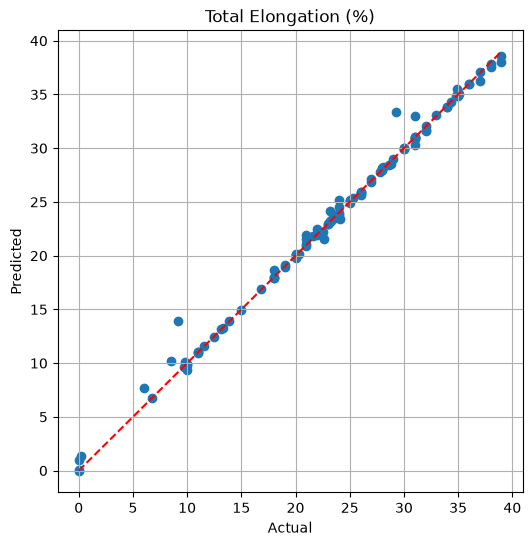

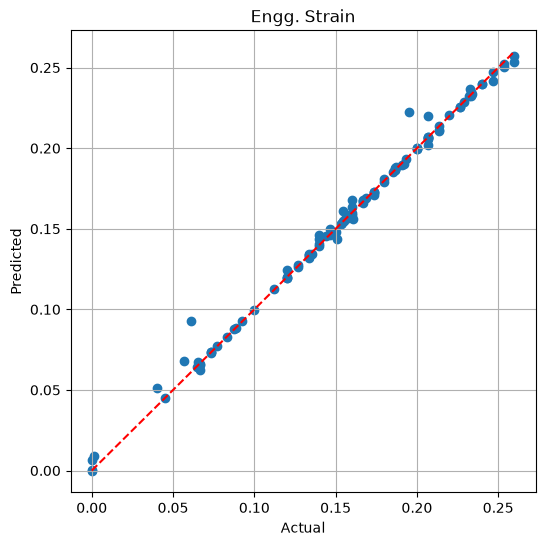

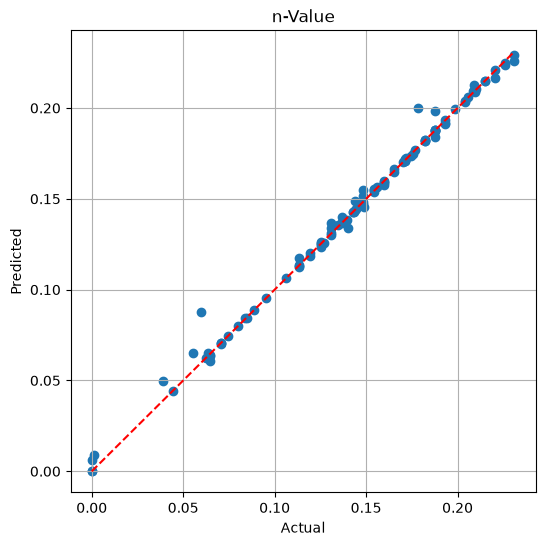

In [93]:
import matplotlib.pyplot as plt

for i, col in enumerate(y.columns):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_validation.iloc[:, i],
        y_pred[:, i]
    )

    plt.plot(
        [
            y_validation.iloc[:, i].min(),
            y_validation.iloc[:, i].max()
        ],
        [
            y_validation.iloc[:, i].min(),
            y_validation.iloc[:, i].max()
        ],
        "r--"
    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(col)

    plt.grid(True)

    plt.show()

In [94]:
X = df.drop(columns=[
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
])

y = df[[
    "UTS (MPa)",
    "YS (MPa)"
]]

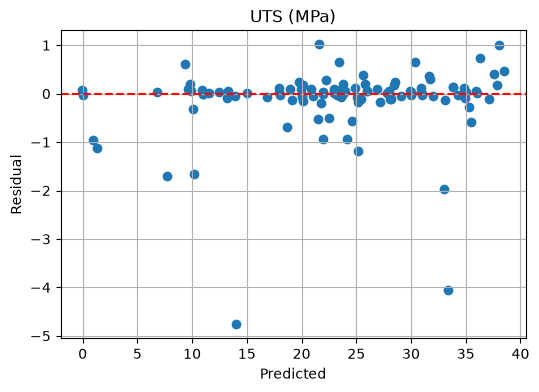

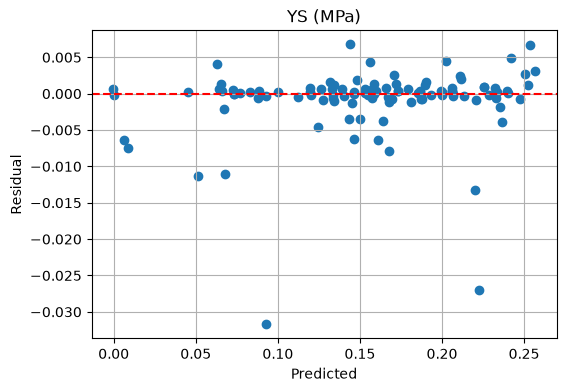

In [95]:
target_columns = ["UTS (MPa)", "YS (MPa)"]
for i, col in enumerate(target_columns):

    residual = (
        y_validation.iloc[:, i] -
        y_pred[:, i]
    )

    plt.figure(figsize=(6,4))

    plt.scatter(
        y_pred[:, i],
        residual
    )

    plt.axhline(
        0,
        color="red",
        linestyle="--"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Residual")

    plt.title(col)

    plt.grid(True)

    plt.show()

In [96]:
cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", MultiOutputRegressor(
        SVR(
            kernel="rbf",
            C=100,
            epsilon=0.1,
            gamma="scale"
        )
    ))
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("\n========== 5 Fold CV ==========")
print("Fold Scores:", scores)
print("Average R²:", scores.mean())
print("Std:", scores.std())


========== 5 Fold CV ==========
Fold Scores: [0.8785712  0.9179266  0.94626726 0.90651406 0.95277321]
Average R²: 0.9204104645262754
Std: 0.027076649389369056


In [97]:
prediction = pd.DataFrame({

    "Actual UTS": y_validation.iloc[:,0],

    "Predicted UTS": y_pred[:,0],

    "Actual YS": y_validation.iloc[:,1],

    "Predicted YS": y_pred[:,1]

})

prediction.to_excel(
    "SVR_Prediction.xlsx",
    index=False
)

print("Prediction Saved")

Prediction Saved


In [98]:
print("\n========== Support Vectors ==========")

for col, est in zip(y.columns, model.estimators_):

    print(
        col,
        ":",
        len(est.support_)
    )


========== Support Vectors ==========
UTS (MPa) : 254
YS (MPa) : 252


In [99]:
print(type(y_validation))
print(type(y_pred))
print(y_validation.shape)
print(y_pred.shape)

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
(112, 3)
(112, 3)


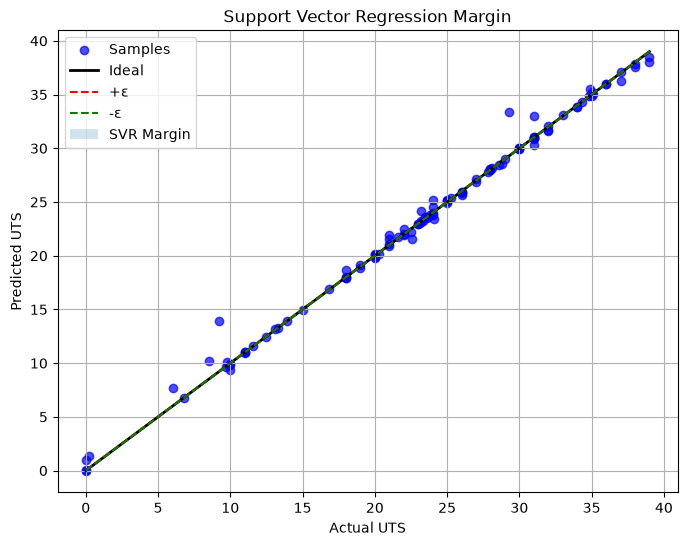

In [100]:
plt.figure(figsize=(8,6))

actual = y_validation.iloc[:,0].values
pred = y_pred[:,0]

plt.scatter(actual, pred,
            color='blue',
            alpha=0.7,
            label='Samples')

plt.plot([actual.min(), actual.max()],
         [actual.min(), actual.max()],
         'k-', lw=2,
         label='Ideal')

epsilon = model.estimators_[0].epsilon

plt.plot([actual.min(), actual.max()],
         [actual.min()+epsilon, actual.max()+epsilon],
         'r--',
         label='+ε')

plt.plot([actual.min(), actual.max()],
         [actual.min()-epsilon, actual.max()-epsilon],
         'g--',
         label='-ε')

plt.fill_between(
    [actual.min(), actual.max()],
    [actual.min()-epsilon, actual.max()-epsilon],
    [actual.min()+epsilon, actual.max()+epsilon],
    alpha=0.2,
    label='SVR Margin'
)

plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.title("Support Vector Regression Margin")
plt.legend()
plt.grid(True)
plt.show()